# Introduction au ML — Séance 7 (TP)
## Valider et régler sans tricher : la validation croisée

**Dr. El Hadji Bassirou TOURÉ** · DMI · FST · UCAD

***

La Séance 6 a laissé deux curseurs en attente — le seuil et `C` — avec l'interdiction de
les régler sur le test. Ce TP construit le protocole complet : la **variance du
découpage** mesurée, la **validation croisée refaite à la main** (avec les équations
normales de la Séance 5 dans chaque pli), `cross_val_score`, les **courbes de
validation**, la **double boucle de GridSearchCV** vérifiée case par case, et le **seuil
du paludisme enfin réglé proprement** par `cross_val_predict`.

**Durée estimée : 1h30.** Exécuter les cellules dans l'ordre, de haut en bas.

## Partie 0 — Mise en place

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
print("Outils prêts. NumPy", np.__version__, "· pandas", pd.__version__)

Outils prêts. NumPy 2.4.4 · pandas 3.0.2


In [2]:
# Ne pas modifier cette cellule : générateur officiel DataSANTÉ-221
def generate_datasante221(n=10_000, seed=221):
    rng = np.random.default_rng(seed)
    age = np.clip(rng.gamma(2.5, 14, n), 5, 85).round(0).astype(int)
    glycemie = np.clip(rng.normal(5.5 + 0.05*age, 1.8), 3.0, 18.0).round(1)
    hemoglobine = np.clip(rng.normal(12.5 - 0.02*age, 1.5), 6.0, 17.0).round(1)
    fievre = np.clip(rng.normal(37.5, 0.9, n), 36.0, 41.5).round(1)
    saison = rng.choice([0, 1], size=n, p=[0.55, 0.45])
    duree = (1.0 + 0.05*age + 0.6*glycemie - 0.3*hemoglobine
             + 1.5*saison + rng.normal(0, 1.8, n)).clip(0.5, 30).round(1)
    proba_palu = 1/(1+np.exp(-(-3 + 1.5*saison + 0.8*(fievre>38.5))))
    palu = (rng.uniform(0,1,n) < proba_palu).astype(int)
    return pd.DataFrame({'age':age,'glycemie':glycemie,'hemoglobine':hemoglobine,
                         'fievre':fievre,'saison':saison,
                         'duree_hospit_j':duree,'paludisme':palu})

df = generate_datasante221()
colonnes = ["age", "glycemie", "hemoglobine", "fievre", "saison"]
print("dimensions :", df.shape)

dimensions : (10000, 7)


## Partie 1 — La variance du découpage : le mal à mesurer

La même recette — Pipeline standardisation + logistique — évaluée sur cinq découpages
train/test différents. Rien ne change sauf la graine du hasard.

In [3]:
# Cinq découpages, cinq AUC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

aucs = []
for rs in range(5):
    X_tr, X_te, y_tr, y_te = train_test_split(df[colonnes], df["paludisme"],
                                              test_size=0.2, random_state=rs,
                                              stratify=df["paludisme"])
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=0))
    m.fit(X_tr, y_tr)
    aucs.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
    print(f"découpage {rs} : AUC = {aucs[-1]:.4f}")
print(f"\nmoyenne = {np.mean(aucs):.4f} · écart-type = {np.std(aucs):.4f} "
      f"· étendue = {max(aucs)-min(aucs):.4f}")

découpage 0 : AUC = 0.6909
découpage 1 : AUC = 0.7024
découpage 2 : AUC = 0.6879
découpage 3 : AUC = 0.7039
découpage 4 : AUC = 0.6923

moyenne = 0.6955 · écart-type = 0.0064 · étendue = 0.0160


**Lecture.** AUC de $0{,}688$ à $0{,}704$ — une étendue de $0{,}016$ sans qu'aucun
choix de modélisation n'ait changé. Un score sur un split unique est une **mesure
bruitée** : comparer deux recettes qui diffèrent de $0{,}01$ sur un seul découpage,
c'est comparer deux nombres dont le bruit propre dépasse l'écart observé.

**Exercice.** Sur un unique découpage, la recette A obtient $0{,}72$ et la recette B
$0{,}73$. Au vu de l'étendue mesurée ci-dessus, écrire en commentaire si l'on peut
déclarer B meilleure — puis vérifier l'intuition en évaluant la même logistique sur les
random_states $5$ à $9$ et en affichant la nouvelle étendue.

In [ ]:
# Cinq découpages supplémentaires (random_state 5 à 9) et leur étendue

## Partie 2 — La validation croisée, à la main

Le jouet : $x = (1,\dots,6)$, $y = (2,2,4,5,5,7)$, trois plis consécutifs. À chaque
tour, la droite est ajustée par les **formules fermées de la Séance 5** sur les quatre
points restants, puis notée (MSE) sur les deux points mis de côté.

In [5]:
# Trois plis, trois équations normales, trois MSE
xj = np.array([1., 2., 3., 4., 5., 6.])
yj = np.array([2., 2., 4., 5., 5., 7.])

from sklearn.model_selection import KFold
kf = KFold(n_splits=3, shuffle=False)
mses = []
for tour, (i_tr, i_va) in enumerate(kf.split(xj), start=1):
    xt, yt = xj[i_tr], yj[i_tr]
    xv, yv = xj[i_va], yj[i_va]
    w = np.sum((xt - xt.mean())*(yt - yt.mean())) / np.sum((xt - xt.mean())**2)
    b = yt.mean() - w*xt.mean()                       # équation normale (Séance 5)
    mse = np.mean((yv - (b + w*xv))**2)
    mses.append(mse)
    print(f"tour {tour} : valide sur {i_va+1}, entraîne sur {i_tr+1} "
          f"-> b={b:.3f}, w={w:.3f}, MSE validation = {mse:.4f}")
print(f"\nverdict CV : moyenne = {np.mean(mses):.4f} · écart-type = {np.std(mses):.4f}")

tour 1 : valide sur [1 2], entraîne sur [3 4 5 6] -> b=1.200, w=0.900, MSE validation = 0.5050
tour 2 : valide sur [3 4], entraîne sur [1 2 5 6] -> b=0.500, w=1.000, MSE validation = 0.2500
tour 3 : valide sur [5 6], entraîne sur [1 2 3 4] -> b=0.500, w=1.100, MSE validation = 0.5050

verdict CV : moyenne = 0.4200 · écart-type = 0.1202


**Lecture.** Trois droites différentes — chaque tour apprend sur des données
différentes — et trois MSE de validation. Le verdict : $\text{CV}_3 = (0{,}505 + 0{,}250
+ 0{,}505)/3 = 0{,}42 \pm 0{,}12$. Et un clin d'œil : le tour $3$, entraîné sur
$\{1,2,3,4\}$, retrouve **exactement** $b = 0{,}5$, $w = 1{,}1$ — le jouet de la
Séance 5, mêmes données, même équation normale, même droite.

In [6]:
# Vérification : cross_val_score rend exactement les trois mêmes MSE
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

scores = cross_val_score(LinearRegression(), xj.reshape(-1, 1), yj,
                         cv=KFold(3, shuffle=False),
                         scoring="neg_mean_squared_error")
print("MSE par pli (sklearn) :", (-scores).round(4))
print("moyenne :", (-scores).mean().round(4))
assert np.allclose(sorted(-scores), sorted(mses))
print("identiques aux calculs à la main — vérifié.")

MSE par pli (sklearn) : [0.505 0.25  0.505]
moyenne : 0.42
identiques aux calculs à la main — vérifié.


**Lecture.** `cross_val_score` ne fait rien de plus que la boucle écrite au-dessus :
découper, entraîner $k$ fois, noter $k$ fois, rendre les $k$ scores. La convention
`neg_mean_squared_error` (signe inversé) existe pour que « plus grand = meilleur » dans
tous les outils de sklearn.

**Important :** la CV n'élit aucune des trois droites. Elle note une **recette** ; le
modèle final se réentraîne ensuite sur les six points.

**Exercice.** Refaire la validation croisée du jouet avec $k = 2$ plis
(`KFold(2, shuffle=False)`) via `cross_val_score`, et comparer la moyenne obtenue au
$0{,}42$ du $k = 3$. Chaque tour n'entraîne plus que sur trois points : que devient le
verdict ?

In [ ]:
# CV à 2 plis sur le jouet, et comparaison avec k=3

## Partie 3 — La stratification : la classe rare dans chaque pli

Sur une cible à $11{,}8\,\%$ de positifs, un pli tiré au hasard peut être anormalement
pauvre ou riche en malades — son verdict est faussé.

In [8]:
# Le découpage de référence du cours (celui des Séances 5 et 6)
X_tr, X_te, y_tr, y_te = train_test_split(df[colonnes], df["paludisme"],
                                          test_size=0.2, random_state=42,
                                          stratify=df["paludisme"])
print("train :", len(y_tr), "patients ·", int(y_tr.sum()), "positifs",
      f"({y_tr.mean():.4f})")

train : 8000 patients · 941 positifs (0.1176)


In [9]:
# Parts de positifs par pli : KFold contre StratifiedKFold
from sklearn.model_selection import StratifiedKFold

y_arr = y_tr.values
for nom, cv in [("KFold          ", KFold(5, shuffle=True, random_state=0)),
                ("StratifiedKFold", StratifiedKFold(5, shuffle=True, random_state=0))]:
    parts = [y_arr[i_va].mean() for _, i_va in cv.split(np.zeros(len(y_arr)), y_arr)]
    print(nom, ":", np.round(parts, 4))

KFold           : [0.1056 0.1281 0.1238 0.1081 0.1225]
StratifiedKFold : [0.1175 0.1175 0.1175 0.1175 0.1181]


**Lecture.** Sans stratification, les plis vont de $10{,}6\,\%$ à $12{,}8\,\%$ de
positifs : chaque tour juge un problème légèrement différent. `StratifiedKFold` impose
la proportion globale à chaque pli. Règle du cours : **classification $\Rightarrow$ plis
stratifiés**, toujours.

In [10]:
# La CV de la logistique du paludisme, dans les règles de l'art
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=0))
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
scores = cross_val_score(pipe, X_tr, y_tr, cv=cv5, scoring="roc_auc")
print("AUC par pli :", scores.round(4))
print(f"verdict CV : {scores.mean():.4f} +/- {scores.std():.4f}")

AUC par pli : [0.7242 0.6778 0.6881 0.6791 0.6881]
verdict CV : 0.6914 +/- 0.0169


**Lecture.** Trois détails du code qui comptent : la recette passée est le
**Pipeline entier** (la standardisation sera refaite à l'intérieur de chaque pli — la
Partie 7 explique pourquoi c'est crucial) ; `scoring="roc_auc"` réutilise la métrique de
la Séance 6 ; et seul l'**entraînement** entre dans la CV — le test n'a pas bougé de
son coffre.

## Partie 4 — Régler un curseur : la courbe de validation

Une note de CV par valeur candidate, et le réglage devient honnête. Premier client :
l'$\alpha$ de Ridge de la Séance 5, qui avait été choisi *en regardant* la validation.

In [11]:
# La sinusoïde exacte de la Séance 5 (mêmes graines, mêmes 50 points)
rng = np.random.default_rng(5)
xs = np.sort(rng.uniform(0, 1, 50))
ys = np.sin(2*np.pi*xs) + rng.normal(0, 0.25, 50)
xs_tr, xs_va, ys_tr, ys_va = train_test_split(xs, ys, test_size=0.4, random_state=0)
print(len(xs_tr), "points d'entraînement —", len(xs_va), "points gardés au coffre")

30 points d'entraînement — 20 points gardés au coffre


In [12]:
# L'alpha de Ridge noté par CV 5 plis, sur les 30 points d'entraînement SEULS
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

alphas = [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100]
rmse_cv = {}
for a in alphas:
    m = make_pipeline(PolynomialFeatures(15), StandardScaler(), Ridge(alpha=a))
    sc = cross_val_score(m, xs_tr.reshape(-1, 1), ys_tr,
                         cv=KFold(5, shuffle=True, random_state=0),
                         scoring="neg_mean_squared_error")
    rmse_cv[a] = np.sqrt(-sc.mean())
    print(f"alpha = {a:7} : RMSE CV = {rmse_cv[a]:.4f}")
meilleur_alpha = min(rmse_cv, key=rmse_cv.get)
print("\nmeilleur alpha (sans avoir touché aux 20 points) :", meilleur_alpha)

alpha =  0.0001 : RMSE CV = 1.3275
alpha =   0.001 : RMSE CV = 0.6915
alpha =    0.01 : RMSE CV = 0.6746


alpha =     0.1 : RMSE CV = 0.4201


alpha =       1 : RMSE CV = 0.6895


alpha =      10 : RMSE CV = 0.4929
alpha =     100 : RMSE CV = 0.8433

meilleur alpha (sans avoir touché aux 20 points) : 0.1


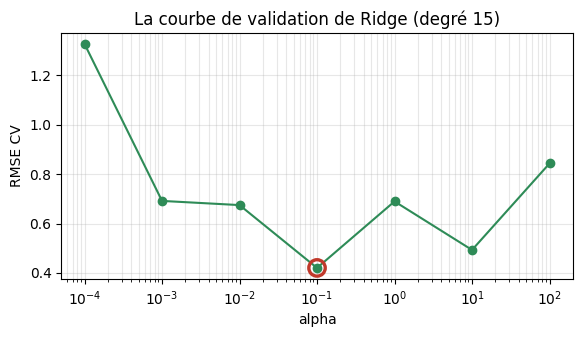

In [13]:
# La courbe de validation
plt.figure(figsize=(6.6, 3.2))
plt.plot(list(rmse_cv.keys()), list(rmse_cv.values()), "o-", color="#2E8B57")
plt.scatter([meilleur_alpha], [rmse_cv[meilleur_alpha]], s=140, facecolors="none",
            edgecolors="#C0392B", lw=2.4, zorder=5)
plt.xscale("log"); plt.xlabel("alpha"); plt.ylabel("RMSE CV")
plt.title("La courbe de validation de Ridge (degré 15)"); plt.grid(alpha=0.3, which="both")
plt.show()

In [14]:
# Le protocole en trois temps : régler par CV, réentraîner, juger UNE fois
from sklearn.metrics import mean_squared_error

m = make_pipeline(PolynomialFeatures(15), StandardScaler(), Ridge(alpha=meilleur_alpha))
m.fit(xs_tr.reshape(-1, 1), ys_tr)
rmse_final = np.sqrt(mean_squared_error(ys_va, m.predict(xs_va.reshape(-1, 1))))
print("verdict final sur les 20 points jamais vus : RMSE =", round(rmse_final, 4))

verdict final sur les 20 points jamais vus : RMSE = 0.3358


**Lecture.** La CV retrouve $\alpha = 0{,}1$ — le choix que la Séance 5 avait fait
*en trichant* (en regardant la validation) est ici retrouvé **sans tricher**, et le
verdict final ($0{,}336$) tombe sur des points que tout le protocole de réglage ignorait.
Au passage : la courbe a une petite bosse à $\alpha = 1$ — avec $30$ points, la CV reste
bruitée ; la tendance se lit, les bosses ne se surinterprètent pas.

In [15]:
# Deuxième client : la profondeur de l'arbre sur la durée d'hospitalisation
from sklearn.tree import DecisionTreeRegressor

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(df[colonnes], df["duree_hospit_j"],
                                              test_size=0.2, random_state=42)
for d in [2, 3, 4, 5, 6, 7, 8, 10, 12]:
    sc = cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=0),
                         Xr_tr, yr_tr, cv=5, scoring="r2")
    print(f"profondeur {d:2d} : R2 CV = {sc.mean():.4f} (+/- {sc.std():.4f})")

profondeur  2 : R2 CV = 0.3980 (+/- 0.0272)
profondeur  3 : R2 CV = 0.4617 (+/- 0.0211)
profondeur  4 : R2 CV = 0.5113 (+/- 0.0207)


profondeur  5 : R2 CV = 0.5471 (+/- 0.0199)


profondeur  6 : R2 CV = 0.5631 (+/- 0.0162)
profondeur  7 : R2 CV = 0.5607 (+/- 0.0134)


profondeur  8 : R2 CV = 0.5407 (+/- 0.0131)


profondeur 10 : R2 CV = 0.4585 (+/- 0.0223)
profondeur 12 : R2 CV = 0.3595 (+/- 0.0322)


**Lecture.** Le $R^2$ monte jusqu'à la profondeur $6$ ($0{,}563$), plafonne, puis
**s'effondre** ($0{,}36$ à $12$) : le U inversé du compromis. La Séance 5 avait découvert
le sur-apprentissage de la profondeur $10$ *après coup*, sur le test ; la CV le voit
**à l'avance**, sans dépenser le test.

**Exercice.** Tracer la courbe de validation de la profondeur (profondeurs en
abscisse, $R^2$ CV en ordonnée), sur le modèle de la courbe de Ridge ci-dessus, et
marquer le pic.

In [ ]:
# La courbe de validation de la profondeur d'arbre

## Partie 5 — Plusieurs curseurs : GridSearchCV

Deux hyperparamètres qui interagissent — la profondeur **et** la taille minimale des
feuilles — se règlent ensemble : une CV par case du produit cartésien.

In [17]:
# La grille arbre sur la durée d'hospitalisation
from sklearn.model_selection import GridSearchCV

grille = {"max_depth": [3, 5, 7, 9], "min_samples_leaf": [1, 20, 100]}
gs = GridSearchCV(DecisionTreeRegressor(random_state=0), grille, cv=5, scoring="r2")
gs.fit(Xr_tr, yr_tr)
print("combinaisons :", len(gs.cv_results_["params"]),
      "· entraînements :", 5*len(gs.cv_results_["params"]), "+ 1 refit")
print("best_params_ :", gs.best_params_)
print("best_score_  :", round(gs.best_score_, 4))

combinaisons : 12 · entraînements : 60 + 1 refit
best_params_ : {'max_depth': 7, 'min_samples_leaf': 20}
best_score_  : 0.5688


In [18]:
# La grille entière, en tableau
res = pd.DataFrame(gs.cv_results_)
res.pivot(index="param_max_depth", columns="param_min_samples_leaf",
          values="mean_test_score").round(4)

param_min_samples_leaf,1,20,100
param_max_depth,,,
3,0.4617,0.4617,0.4617
5,0.5471,0.5468,0.5436
7,0.5607,0.5688,0.5547
9,0.5008,0.5607,0.5546


In [19]:
# La double boucle de GridSearchCV, refaite à la main sur UNE case : (5, 20)
sc = cross_val_score(DecisionTreeRegressor(max_depth=5, min_samples_leaf=20,
                                           random_state=0),
                     Xr_tr, yr_tr, cv=5, scoring="r2")
print("scores des 5 plis :", sc.round(4))
print("moyenne :", round(sc.mean(), 4), " — la valeur inscrite dans la case (5, 20)")

scores des 5 plis : [0.5485 0.5324 0.5194 0.5791 0.5544]
moyenne : 0.5468  — la valeur inscrite dans la case (5, 20)


**Lecture.** `GridSearchCV` n'est que deux boucles — *pour chaque combinaison, pour
chaque pli* — et la case $(5, 20)$ refaite à la main ($0{,}5468$) coïncide avec le
tableau. L'interaction se lit dans la ligne $9$ : la profondeur $9$ n'est bonne *que*
si les feuilles sont contraintes ($0{,}501$ avec feuilles libres, $0{,}561$ avec $20$).

In [20]:
# Le verdict : gs est déjà le modèle final (refit sur tout le train)
print("R2 sur le test (une seule fois) :", round(gs.score(Xr_te, yr_te), 4))

R2 sur le test (une seule fois) : 0.5545


**Lecture.** `best_score_` ($0{,}569$) et le verdict test ($0{,}554$) diffèrent
légèrement — normal : le meilleur d'une grille est un *maximum de mesures bruitées*,
donc un peu optimiste. C'est précisément pour cela que le verdict se prend sur le test,
jamais sur `best_score_`.

**Exercice.** Une grille croise $4$ valeurs de `C`, $2$ valeurs de `class_weight` et
$5$ valeurs de seuil, en CV à $5$ plis. Calculer (en Python) le nombre de combinaisons et
le nombre total d'entraînements refit compris, puis le temps total si un entraînement
prend $2$ secondes.

In [ ]:
# Combinaisons, entraînements (refit compris), temps total à 2 s/entraînement

## Partie 6 — Le seuil du paludisme, réglé proprement

Le fil laissé par la Séance 6. `cross_val_predict` fournit, pour chaque patient de
l'entraînement, la probabilité prédite **par le tour de CV qui ne l'a pas vu** : des
probabilités honnêtes, parfaites pour balayer un seuil.

In [22]:
# Des probabilités honnêtes sur TOUT l'entraînement
from sklearn.model_selection import cross_val_predict

proba_cv = cross_val_predict(pipe, X_tr, y_tr, cv=cv5, method="predict_proba")[:, 1]
print("une probabilité par patient d'entraînement :", proba_cv.shape)
print("AUC de ces probabilités :", round(roc_auc_score(y_tr, proba_cv), 4))

une probabilité par patient d'entraînement : (8000,)
AUC de ces probabilités : 0.6895


In [23]:
# Le balayage de la Séance 6 — mais sur les probabilités CV, pas sur le test
yv = y_tr.values
candidats = np.arange(0.05, 0.30, 0.005)
admissibles = []
for s in candidats:
    yh = (proba_cv >= s).astype(int)
    tp = int(((yh == 1) & (yv == 1)).sum())
    fp = int(((yh == 1) & (yv == 0)).sum())
    fn = int(((yh == 0) & (yv == 1)).sum())
    rec = tp/(tp + fn)
    if rec >= 0.75 and tp + fp > 0:
        admissibles.append((s, tp/(tp + fp), rec))
s_cv, p_cv, r_cv = max(admissibles, key=lambda t: t[1])
print(f"seuil retenu : {s_cv:.3f} (precision CV {p_cv:.3f} · recall CV {r_cv:.3f})")

seuil retenu : 0.125 (precision CV 0.200 · recall CV 0.751)


In [24]:
# Réentraîner sur tout le train, puis verdict unique sur le test
pipe.fit(X_tr, y_tr)
proba_te = pipe.predict_proba(X_te)[:, 1]
yh = (proba_te >= s_cv).astype(int)
tp = int(((yh == 1) & (y_te == 1)).sum())
fp = int(((yh == 1) & (y_te == 0)).sum())
fn = int(((yh == 0) & (y_te == 1)).sum())
print(f"verdict test : precision = {tp/(tp+fp):.3f} · recall = {tp/(tp+fn):.3f}")

verdict test : precision = 0.205 · recall = 0.796


**Lecture.** Seuil $0{,}125$ choisi sur les probabilités CV (recall promis :
$0{,}751$) — et le test, ouvert une seule fois, confirme : recall $0{,}796$. À comparer
au mini-défi de la Séance 6 : le seuil « optimal » trouvé *en regardant le test*
affichait un chiffre du même ordre, mais ce chiffre ne **prouvait** rien — celui-ci, si.

**Exercice.** Reprendre le balayage ci-dessus avec une mission plus stricte : recall
$\geq 0{,}78$ sur les probabilités CV. Afficher le seuil retenu et son verdict test.

In [ ]:
# Mission recall >= 0,78 : seuil par CV, puis verdict test

## Partie 7 — Le piège : standardiser avant de découper

Standardiser **tout** l'entraînement puis lancer la CV est une fuite : la moyenne et
l'écart-type de chaque tour ont vu les données du pli de validation. Le Pipeline règle
le problème en refaisant la standardisation *à l'intérieur* de chaque tour.

In [26]:
# Le pattern FAUTIF (à reconnaître) contre le pattern CORRECT (à pratiquer)
# --- fautif : le scaler voit tout le train avant la CV
scaler = StandardScaler().fit(X_tr)                  # <- a vu les futurs plis de validation
X_tr_std = scaler.transform(X_tr)
auc_fautif = cross_val_score(LogisticRegression(max_iter=1000, random_state=0),
                             X_tr_std, y_tr, cv=cv5, scoring="roc_auc").mean()

# --- correct : le Pipeline refait le scaler dans chaque tour
auc_correct = cross_val_score(pipe, X_tr, y_tr, cv=cv5, scoring="roc_auc").mean()

print(f"AUC CV, pattern fautif  : {auc_fautif:.4f}")
print(f"AUC CV, pattern correct : {auc_correct:.4f}")

AUC CV, pattern fautif  : 0.6914
AUC CV, pattern correct : 0.6914


**Lecture.** Ici l'écart est minuscule — la standardisation ne « vole » que deux
moyennes et deux écarts-types, peu d'information sur $8\,000$ patients. Mais le principe
ne se négocie pas : avec des préprocesseurs plus gourmands (imputation, sélection de
variables, encodages appris), la fuite gonfle le score CV de façon parfois spectaculaire.
Réflexe : **tout ce qui apprend des données vit dans le Pipeline**, et c'est le Pipeline
entier qui entre dans la CV.

## Mini-défi — L'arbre peut-il battre la logistique ?

La Séance 6 a couronné la logistique (AUC test $0{,}714$). L'arbre de la Séance 3, jugé à
l'accuracy, semblait inutile sur le paludisme. Avec les bons outils — AUC, CV,
GridSearchCV — donner à l'arbre une seconde chance.

In [27]:
# La profondeur d'arbre réglée par CV stratifiée, métrique AUC
from sklearn.tree import DecisionTreeClassifier

gs_arbre = GridSearchCV(DecisionTreeClassifier(random_state=0),
                        {"max_depth": [2, 3, 4, 5, 7, 10]},
                        cv=cv5, scoring="roc_auc")
gs_arbre.fit(X_tr, y_tr)
for p, s in zip(gs_arbre.cv_results_["params"], gs_arbre.cv_results_["mean_test_score"]):
    print(f"profondeur {p['max_depth']:2d} : AUC CV = {s:.4f}")
print("\nmeilleure profondeur :", gs_arbre.best_params_["max_depth"])

profondeur  2 : AUC CV = 0.6927
profondeur  3 : AUC CV = 0.6955
profondeur  4 : AUC CV = 0.6889
profondeur  5 : AUC CV = 0.6717
profondeur  7 : AUC CV = 0.6574
profondeur 10 : AUC CV = 0.6047

meilleure profondeur : 3


In [28]:
# Le verdict, une seule fois
auc_arbre = roc_auc_score(y_te, gs_arbre.predict_proba(X_te)[:, 1])
print("AUC test de l'arbre réglé :", round(auc_arbre, 4))
print("rappel — AUC test de la logistique (Séance 6) : 0.714")

AUC test de l'arbre réglé : 0.7272
rappel — AUC test de la logistique (Séance 6) : 0.714


**Lecture.** L'arbre, réglé proprement (profondeur $3$ par CV — les profondeurs
$7$ et $10$ s'effondrent), atteint **AUC $0{,}727$** : il fait jeu égal avec la
logistique, voire un peu mieux. Le « modèle inutile » de la Séance 3 ne manquait ni de
capacité ni d'idées — il manquait de **métriques** (Séance 6) et de **protocole**
(Séance 7).

Mais un arbre seul plafonne vite : peu de profondeur autorisée, sous peine de
sur-apprentissage. Et si, au lieu d'un arbre soigneusement bridé, on en entraînait
*cent* — chacun un peu différent — et qu'on les faisait **voter** ? C'est l'idée des
**forêts aléatoires**, et c'est la **Séance 8**.

## Synthèse — à compléter

1. Toute donnée qui a servi à **..........** ne peut plus servir à **..........** ; le
   test ne s'ouvre qu'**..........** fois.
2. Un score sur un split unique est une mesure **..........** ; la CV à $k$ plis rend
   une **..........** et un **..........** qui mesurent le niveau et le bruit.
3. La CV évalue une **..........**, pas un modèle : le modèle final se **..........**
   sur tout l'entraînement.
4. En classification, les plis doivent être **..........** ; le défaut du cours est
   $k = $ **..........**.
5. Un curseur se règle par **..........**, plusieurs par **..........**
   (coût $= |\text{grille}| \times k + 1$), et le seuil par **..........**.
6. Tout préprocesseur vit dans le **..........**, sinon la CV fuit ; `best_score_` est
   **..........** — seul le test tranche.